## EDA Understandings:
1. Extremely imbalanced (~3% Anomalies)
2. Longer sequence lengths(>75) have higher chance of anomaly(9%) compared to overall rate(3%)
3. Certain events like 5,6,11,12,34 occur moer frequently in Anomalies compared to Normal blocks. This is expected, as these perhaps represent events such as exceptions or failures
<br>

___

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

In [7]:
df = pd.read_csv('../datasets/HDFS_v1/prepared_df.csv')
df['events_sequence'] = df['events_sequence'].apply(ast.literal_eval)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 575061 entries, 0 to 575060
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   blk_id           575061 non-null  str   
 1   events_sequence  575061 non-null  object
 2   Label            575061 non-null  int64 
dtypes: int64(1), object(1), str(1)
memory usage: 13.2+ MB


In [9]:
df.sample(10)

,blk_id,events_sequence,Label
356563,blk_6056846765877509972,"[1, 0, 0, 0, 2, 3, 2, 3, 2, 3, 4, 4, 4]",0
17809,blk_6317676091140752890,"[1, 0]",1
91405,blk_987290183116285515,"[1, 0, 0, 0, 4, 4, 4, 2, 3, 2, 3, 2, 3, 36, 9,...",0
438377,blk_6982771675114032214,"[0, 0, 1, 0, 2, 3, 2, 3, 2, 3, 4, 4, 4, 33, 33...",1
521706,blk_-1266765437380524186,"[0, 0, 0, 1, 2, 3, 2, 3, 2, 3, 4, 4, 4]",0
534019,blk_5101205978170906352,"[0, 0, 0, 1, 2, 3, 2, 3, 2, 3, 4, 4, 4]",0
401213,blk_-1319530820360735054,"[0, 0, 0, 1, 2, 3, 2, 3, 2, 3, 4, 4, 4, 33, 33...",0
126191,blk_-8198701115882663,"[1, 0, 0, 0, 4, 4, 2, 3, 2, 3, 4, 2, 3, 12, 36...",0
465060,blk_-8916199205347280130,"[0, 0, 0, 1, 2, 3, 2, 3, 2, 3, 4, 4, 4, 33, 33...",0
429553,blk_-3518431150444839650,"[0, 0, 0, 1, 2, 3, 2, 3, 2, 3, 4, 4, 4, 33, 33...",0


___
___

In [18]:
df['Label'].value_counts(normalize=True)

Label
0    0.97072
1    0.02928
Name: proportion, dtype: float64

In [20]:
df['seq_len'] = df['events_sequence'].apply(len)
df['seq_len'].describe()

count    575061.000000
mean         19.433815
std           5.177735
min           2.000000
25%          19.000000
50%          19.000000
75%          20.000000
max         298.000000
Name: seq_len, dtype: float64

In [40]:
df['seq_len'].value_counts(bins=[25,50,75,200,225,250,275,300])

(24.999, 50.0]    76884
(250.0, 275.0]       18
(200.0, 225.0]       17
(50.0, 75.0]         11
(275.0, 300.0]        5
(225.0, 250.0]        4
(75.0, 200.0]         0
Name: count, dtype: int64

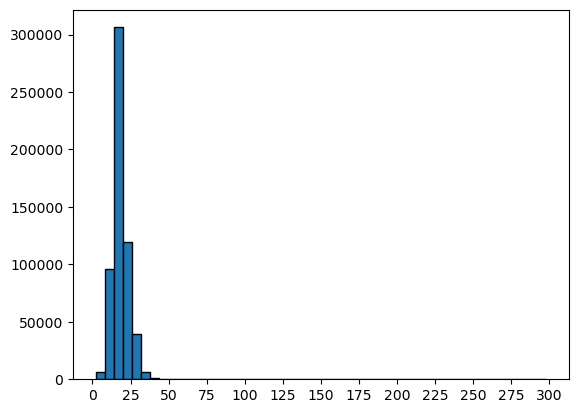

In [89]:
df['seq_len'].hist(bins=50, edgecolor='black')
plt.xticks([0,25,50,75,100,125,150,175,200,225,250,275,300])
plt.grid(False)
plt.savefig('SequenceLengthDistribution.png', dpi=200, format='png')
plt.show()

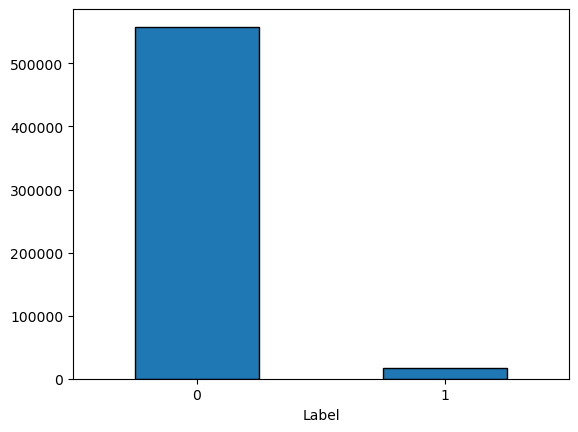

In [104]:
df.loc[(df['seq_len']<75)]['Label'].value_counts().sort_index().plot(kind='bar', edgecolor='black')
plt.xticks(rotation=0)
plt.grid(False)
plt.savefig('ShortLengthDistribution.png', dpi=200, format='png')
plt.show()

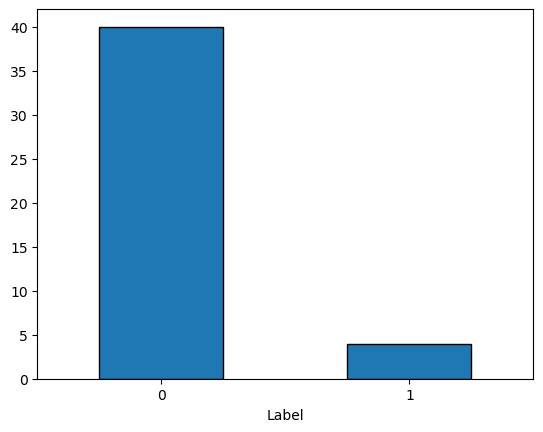

In [105]:
df.loc[(df['seq_len']>75)]['Label'].value_counts().sort_index().plot(kind='bar', edgecolor='black')
plt.xticks(rotation=0)
plt.grid(False)
plt.savefig('LongLengthDistribution.png', dpi=200, format='png')
plt.show()

In [43]:
df.loc[(df['seq_len']>75) & (df['seq_len']<300), 'Label'].value_counts()

Label
0    40
1     4
Name: count, dtype: int64

### Checking event distribution

In [44]:
from collections import Counter

all_events = [e for seq in df['events_sequence'] for e in seq]
event_counts = Counter(all_events)

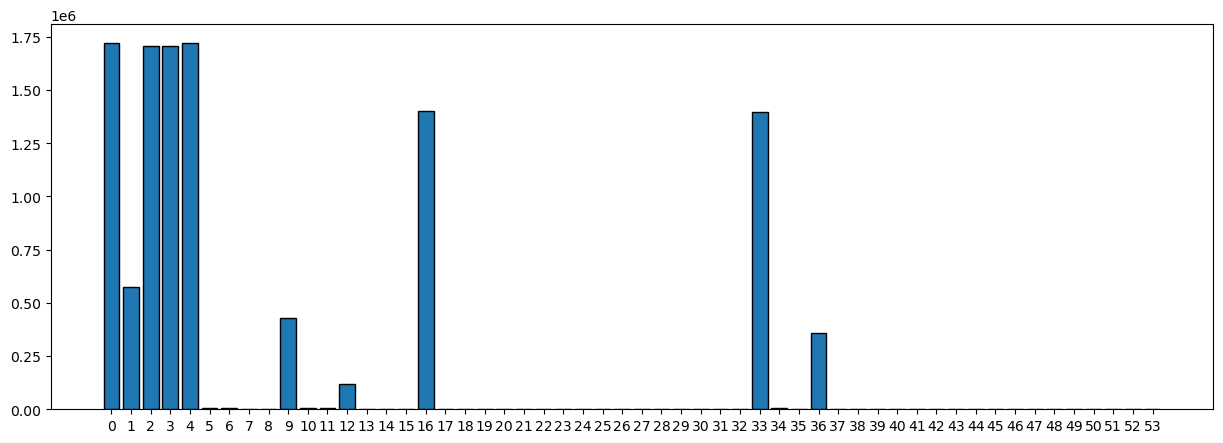

In [80]:
plt.figure(figsize=(15,5))
plt.bar(event_counts.keys(), event_counts.values(), edgecolor='black')
plt.xticks(list(event_counts.keys()))
plt.savefig('EventFrequencyNormal.png', dpi=200, format='png')
plt.show()

In [62]:
anomaly_events = [e for seq in df.loc[(df['Label']==1)]['events_sequence'] for e in seq]
anomaly_counts = Counter(anomaly_events)

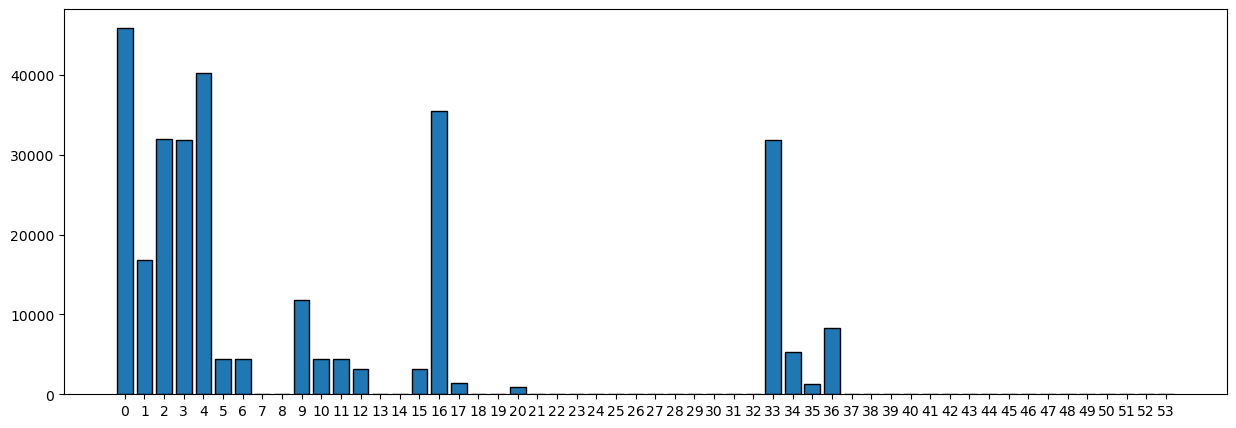

In [81]:
plt.figure(figsize=(15,5))
plt.bar(anomaly_counts.keys(), anomaly_counts.values(), edgecolor='black')
plt.xticks(list(anomaly_counts.keys()))
plt.savefig('EventFrequencyAnomaly.png', dpi=200, format='png')
plt.show()

### Insights
Events like 5, 6, 10, 11, 34 appear mor frequently in anomalies